# Extrapolation and blending

PHOEBE uses model atmospheres to compute emergent specific intensities from the local atmospheric parameters (effective temperature, surface gravity, helium abundances, heavy metal abundances) for each surface element. There are multiple model atmospheres that PHOEBE supports: Castelli & Kurucz, PHOENIX, TMAP, and Tremblay. Each model atmosphere is tuned to a specific range of atmospheric parameters and computed using a specific set of assumptions. Model atmosphere tables are precomputed in many combinations of model parameters, forming a multi-dimensional grid. See [Advanced: Model Atmospheres Tutorial](atm_advanced.ipynb) and [Jones et al. (2006)](https://phoebe-project.org/publications/2026Jones+) for details.

Due to tidal and/or rotational distortion, irradiation, and other physical circumstances, it can happen that some of the surface elements on the star fall off the grid of valid model atmosphere parameters. When that happens, PHOEBE enables you to choose how to handle the intensities coming from such surface elements. The three parameters that control the behavior are `atm_extrapolation_method`, `ld_extrapolation_method` and `blending_method`. We explain their use here and demonstrate it on a semi-detached binary case.

Setup
-----------------------------

Let's first make sure we have the latest version of PHOEBE 2.5 installed (uncomment this line if running in an online notebook session such as colab).

In [ ]:
#!pip install -I "phoebe>=2.5"

In [11]:
import phoebe

Now instantiate a semi-detached binary star where the secondary fills its Roche lobe:

In [12]:
b = phoebe.default_binary(semidetached='secondary')
b.set_value(qualifier='teff', component='primary', value=4500)
b.set_value(qualifier='teff', component='secondary', value=3600)

Add a light curve and a mesh at phase 0.30:

In [13]:
b.add_dataset(
    'lc',
    compute_phases=phoebe.linspace(-0.6, 0.6, 201),
    passband='Johnson:V',
    dataset='lc01'
)

b.add_dataset(
    'mesh',
    compute_phases=[0.30,],
    passband='Johnson:V',
    columns=['teffs', 'intensities*', 'blending_factors*', 'extrapolation_dists*'],
    dataset='mesh01'
)

<ParameterSet: 85 parameters | contexts: constraint, compute, dataset, figure>


### atm_extrapolation_method

This option tells PHOEBE whether or not to extrapolate atmospheric parameters off-grid. The parameter has 3 choices: 'none', 'nearest', and 'linear'.

* 'none' disables extrapolation; nans are returned for all surface elements that are off-grid;
* 'nearest' enables extrapolation; it sets atmospheric parameters to the nearest defined vertex in the model atmosphere grid;
* 'linear' enables extrapolation; it computes intensities from linearly extrapolated parameters.

The default value, 'linear', is appropriate when excursions from the model atmosphere grid are small. As the distance from the grid increases, extrapolated values will become increasingly less reliable. To avoid large extrapolation errors, atm_extrapolation_method can be switched to 'nearest', which will assume the values of the nearest combination of atmospheric parameters on the grid. If you need strict adherence to the model atmosphere, switch it to 'none'. In that case, any off-grid elements will be returned as nan.

Let us inspect the parameter and compute the light curve and the mesh for all three cases:

In [14]:
print(b.filter(qualifier='atm_extrapolation_method'))
print(b.get_parameter(qualifier='atm_extrapolation_method', component='secondary'))

ParameterSet: 2 parameters
   atm_extrapolation_method@pr...: linear
   atm_extrapolation_method@se...: linear
Parameter: atm_extrapolation_method@secondary@phoebe01@compute
                       Qualifier: atm_extrapolation_method
                     Description: Method of extrapolating intensities outside of the atmosphere grid
                           Value: linear
                         Choices: none, nearest, linear
                  Constrained by: 
                      Constrains: None
                      Related to: None
                 Only visible if: atm:!blackbody,atm:!extern_planckint,atm:!extern_atmx



In [15]:
extrapolation_methods = b.get_parameter(qualifier='atm_extrapolation_method', component='secondary').choices
for extrapolation_method in extrapolation_methods:
    b.set_value(qualifier='atm_extrapolation_method', component='secondary', value=extrapolation_method)
    b.run_compute(model=f"ext_{extrapolation_method}")

100%|██████████| 202/202 [00:02<00:00, 71.20it/s] 


Let's plot the results where we will color-code the mesh of the secondary star by effective temperature:

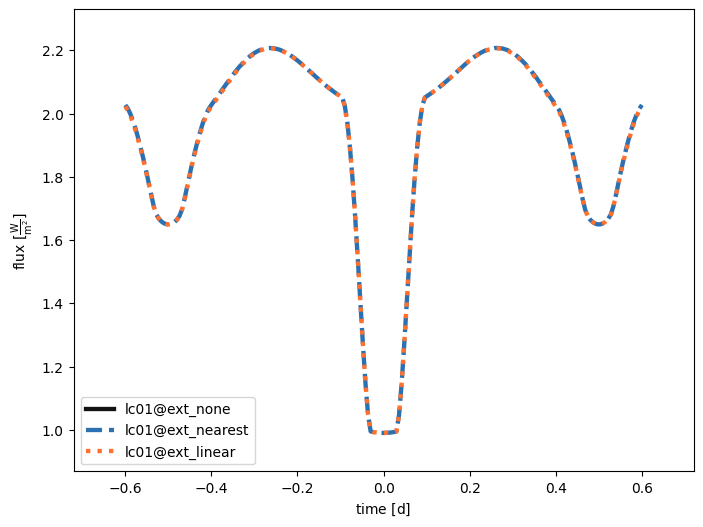

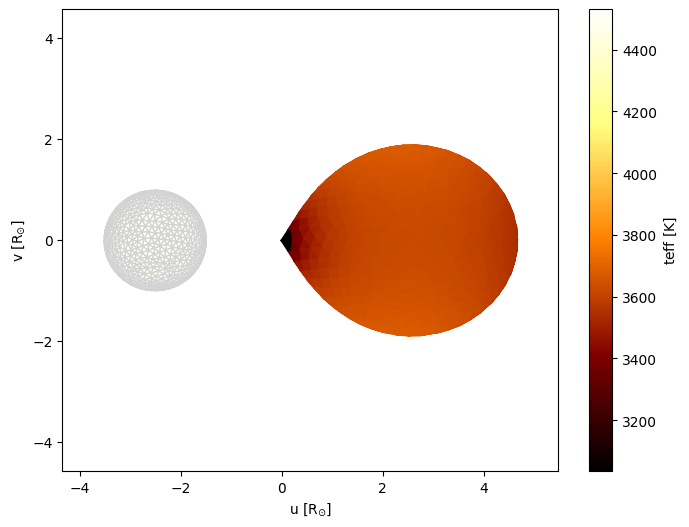

In [16]:
b.plot(kind='lc', show=True, legend=True);
b.plot(model='ext_none', kind='mesh', fc='teffs', ec={'primary': 'lightgrey', 'secondary': 'teffs'}, show=True, draw_sidebars=True);

As the default model atmosphere, Castelli & Kurucz, does not support temperatures below 3500K, we can immediately understand why light curve for `atm_extrapolation_method=none` is not plotted: if *any* of the intensities are nan, the flux will sum up to nan and there will be no useful data:

In [17]:
# intensities:
print(b.get_value(qualifier='intensities', component='secondary', model='ext_none'))

# fluxes:
print(b.get_value(qualifier='fluxes', model='ext_none'))

[           nan            nan            nan ... 9.59517861e-13
 1.05988481e-12 9.68614963e-13]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan]


This is precisely the problem that extrapolation overcomes: there may be only a handful of surface elements that are out of bounds, but the entire light curve computation fails because of that. Looking at the mesh plot, it seems that all such surface elements are near the point-radius. We can take a look at how far from the grid they are, in grid step units:

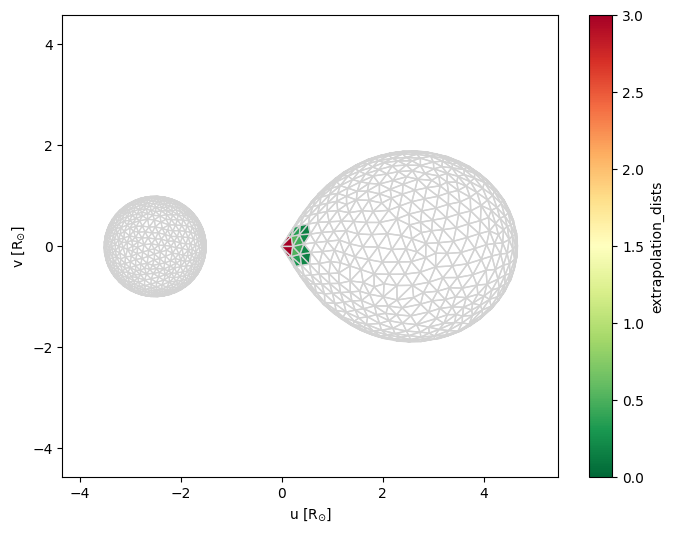

(<autofig.figure.Figure | 1 axes | 2 call(s)>,
 <Figure size 800x600 with 2 Axes>)

In [18]:
b.plot(model='ext_nearest', kind='mesh', fc={'secondary': 'extrapolation_dists'}, ec='lightgrey', show=True, draw_sidebars=True)

Notice, of course, that we could not have used 'ext_none' here -- as there is no extrapolation, distances were not computed either. Hence, we had to use 'ext_nearest' or 'ext_linear', to enable extrapolation.

Next notice that, indeed, there are only a handful of triangles that are below 3500K (depicted in green and red), precisely towards the primary component. As the grid step size is 250K, dark green elements are *just* off-grid, light green elements are ~150K off grid, and red elements are ~500K off grid. This is in line with what we had seen in the temperature mesh plot above.

Finally, it now becomes obvious why 'ext_nearest' and 'ext_linear' models are inidistinguishable: those few surface elements make precious little difference. It also justifies the use of extrapolation: in its absence, we would need to fall back to blackbody model atmospheres, which are vastly inferior to Castelli & Kurucz models.

### ld_extrapolation_method

The other principal purpose of model atmospheres is to provide realistic [limb darkening prescriptions](https://phoebe-project.org/docs/latest/tutorials/limb_darkening). If parameters are in bounds, then limb darkening can be automatically interpolated (`ld_mode=interp`). However, when out of bounds, this then fails, and PHOEBE provides equivalent options for governing the mode of operation. There is, however, one crucial distinction: limb darkening coefficients are much less linear as a function of atmospheric parameters than intensities. That is why the default value is set to 'nearest' and not 'linear'.

### blending_method

The final operation that governs off-grid behavior is *blending*. We established above that, with the increasing distance from the grid, extrapolation becomes unreliable. We are then presented with the two choices: we can live with extrapolation uncertainties, or we can progressively ramp towards a more reliable model -- the blackbody model atmosphere. This gradual transition from extrapolated values to blackbody values we refer to as *blending*. Blending is governed by the `blending_method` parameter in PHOEBE.

The parameter has two possible values, 'none' and 'blackbody'. It instructs PHOEBE to either avoid blending (`blending_method='none'`) or to ramp to the blackbody atmosphere (`blending_method='blackbody'`). Blending multiple model atmospheres is not practical because each model is tuned to a particular set of physical circumstances, so the only useful choice is blending into blackbody atmosphere.

To blend or not to blend? For the most part, blending is a reasonable choice. When close to the grid, extrapolation will dominate; when far from the grid, blackbody will dominate. The transition between the two cases is gradual. Thus, the default in PHOEBE for blending is `blackbody`.

We can now see what blending factors we get for the model above:

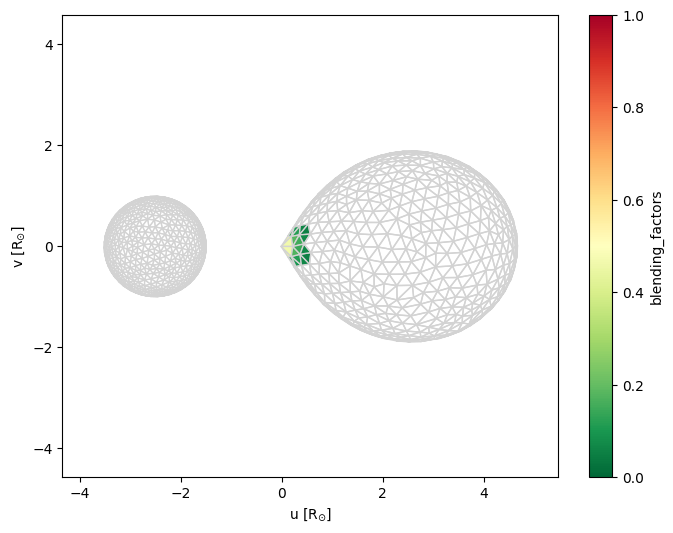

In [19]:
b.plot(model='ext_nearest', kind='mesh', fc={'secondary': 'blending_factors'}, ec='lightgrey', show=True, draw_sidebars=True);

Thus, the very tip of the star if blended ~50-50 with the blackbody intensities, while the surrounding areas are largely extrapolated.